# Part 2. ODE

## Computing $\mathcal{L}(u)$ via an ODE scheme

### Definitions

Recall that we consider the Laplace transform of a log-normally distributed random variable, which without loss of generality can be reduced to the integral
$$\mathcal{L}(u)=\int_{-\infty}^{\infty} \exp\left(-u\cdot e^y\right)\phi(y)\, dy,$$
where $\phi(y)$ is the PDF of a normally distributed random variable $Y\sim\mathcal{N}(0,\sigma^2)$ with variance $v=\sigma^2$.

Introduce the unnormalized density $p_u(x)=\exp\left(-u\cdot e^x\right)\phi(x)$, which corresponds to the finite positive measure $\mu_u(dx)=p_u(x)\,dx$ of total mass $\int_{\mathbb{R}}p_u(x)\,dx=\mathcal{L}(u)<\infty$. Define the unnormalized expectation of a function $f$ of a random variable $X$ with unnormalized density $p_u(x)$ as the linear functional
$$\mathbb{E}_u[f(X)]=\int_{\mathbb{R}}f(x)\,p_u(x)\,dx.$$

The moments of $X$ are then written in the usual way:
$$m_k(u)=\mathbb{E}_u[X^k]<\infty,$$
and we may introduce the unnormalized moment-generating function
$$\mathcal{M}(z,u)=\mathbb{E}_u[e^{zX}].$$
Note that for all $u\ge0$ and $z\in\mathbb{R}$ the quantity $\mathcal{M}(z,u)$ is finite, positive and well-defined. Moreover, when $u>0$ the integral converges for every complex $z$, so that $\mathcal{M}(z,u)$ is an entire function of $z$; this fact will be used later. Taking the logarithm of $\mathcal{M}(z,u)$ yields the cumulant-generating function
$$\mathcal{C}(z,u)=\ln\mathcal{M}(z,u).$$

### Properties

Differentiate $\mathcal{M}(z,u)$ with respect to $u$:
$$\frac{\partial}{\partial u}\mathcal{M}(z,u)=\int_{\mathbb{R}}\frac{\partial}{\partial u}\exp\left(z\cdot x-u\cdot e^x\right)\phi(x)\,dx=-\int_{\mathbb{R}}e^x\exp\left(z\cdot x-u\cdot e^x\right)\phi(x)\,dx=-\int_{\mathbb{R}}\exp\left((z+1)\cdot x-u\cdot e^x\right)\phi(x)\,dx=-\mathcal{M}(z+1,u).$$
Divide both sides by $\mathcal{M}(z,u)$:
$$\frac{\frac{\partial}{\partial u}\mathcal{M}(z,u)}{\mathcal{M}(z,u)}=-\frac{\mathcal{M}(z+1,u)}{\mathcal{M}(z,u)}.$$
The left-hand side is precisely the derivative of $\mathcal{C}(z,u)$; expressing the right-hand side in terms of $\mathcal{C}$ as well gives
$$\frac{\partial}{\partial u}\mathcal{C}(z,u)=-\exp\bigl(\mathcal{C}(z+1,u)-\mathcal{C}(z,u)\bigr).$$
Introduce the forward-difference operator
$$\Delta_z f(z)\coloneqq f(z+1)-f(z);$$
then
$$\frac{\partial}{\partial u}\mathcal{C}(z,u)=-\exp\bigl(\Delta_z\mathcal{C}(z,u)\bigr).$$

Denote $\exp\bigl(\Delta_z\mathcal{C}(z,u)\bigr)$ by $R(z,u)$ and expand both sides in powers of $z$ about the origin. Since the derivatives of $\mathcal{C}$ at zero are the corresponding cumulants $\kappa_k$, we obtain
$$\frac{\partial}{\partial u}\sum_{k=0}^\infty\frac{z^k}{k!}\kappa_k(u)=-\sum_{k=0}^\infty\frac{z^k}{k!}\left.\frac{\partial^k R}{\partial z^k}\right|_{z=0}.$$
Here $\kappa_0(u)$, because of the lack of normalization, equals $\ln\mathcal{L}(u)$, while the zeroth derivative on the right-hand side is simply $R(0,u)$. Equating coefficients of like powers of $z$ and writing a dot for differentiation with respect to $u$ yields the infinite system
$$\dot{\kappa}_k=-\left.\frac{\partial^k R(z,u)}{\partial z^k}\right|_{z=0},\qquad k=0,1,\dots$$
with initial conditions $\kappa_k(0)=0$ except for $\kappa_2(0)=v$ (when $u=0$ the measure reduces to $\mathcal{N}(0,v)$ and $\mathcal{C}(z,0)=vz^2/2$). The quantity of interest in this system is $\kappa_0$: exponentiating it recovers $\mathcal{L}(u)$.

### Constructing an approximation to $\mathcal{L}(u)$

Solving the infinite system is impractical. We therefore construct a sequence of finite-dimensional approximations. Let
$$\mathcal{C}_n=\sum_{k=0}^n p_k(u)z^k,$$
where $p_k(u)$ is intended to approximate $\kappa_k/k!$; i.e., we simply truncate the series after $n$ terms. Write $[z^k]f(z)$ for the coefficient of $z^k$ in the expansion of $f(z)$:
$$[z^k]f(z)=\frac1{k!}\left.\frac{d^k}{dz^k}f(z)\right|_{z=0}.$$
This produces the closed system of ordinary differential equations
$$\dot{p}_k=-[z^k]e^{\Delta_z\mathcal{C}_n(z,u)},\qquad p_2(0)=v/2,\quad p_{k\neq2}(0)=0,\quad k=0,\dots,n. \tag{1}$$

The exponential of $p_0(u)$ then supplies an approximation that, one hopes, converges to $\mathcal{L}(u)$ as $n$ increases.

### Efficient evaluation of $[z^k]e^{\Delta_z\mathcal{C}_n(z,u)}$

Express the difference $\Delta_z\mathcal{C}_n(z)=\mathcal{C}_n(z+1)-\mathcal{C}_n(z)$, which is a polynomial $Q(z)$ of degree $n-1$, by means of the binomial-coefficient matrix:
$$Q(z)=\mathcal{C}_n(1+z)-\mathcal{C}_n(z)=\sum_{i=0}^n p_i\bigl((1+z)^i-z^i\bigr)=\sum_{i=1}^n p_i\Bigl(\sum_{j=0}^i\binom{i}{j}z^j-z^i\Bigr)=\mathbf{p}_1^T\cdot\mathbf{S}\cdot\mathbf{z},$$
where $\mathbf{p}_1$ is the column vector $(p_1,\dots,p_n)$, $\mathbf{z}$ is the column vector $(1,z,\dots,z^{n-1})$, and the lower-triangular $n\times n$ matrix $\mathbf{S}$ is built from binomial coefficients (row $i=0,\dots,n-1$ corresponds to $p_{i+1}$, column $j$ to the power $z^j$):
$$S_{ij}=\begin{cases}\binom{i+1}{j}&j\le i,\\0&\text{otherwise}.\end{cases}$$
An efficient procedure for extracting $[z^k]e^{Q(z)}$ for arbitrarily large $k$ is required.

Write
$$Q(z)=\sum_{j\ge0}q_j z^j.$$
Although the true degree of $Q$ is only $n-1$, we derive the recurrence in full generality and afterwards set the superfluous coefficients $q_n,q_{n+1},\dots$ to zero.

Consider the formal power series
$$G(z)\coloneqq e^{Q(z)}=\sum_{m\ge0}g_m z^m.$$
The coefficients $g_m$ are precisely what enter system (1):
$$g_m=[z^m]e^{Q(z)}=[z^m]e^{\Delta_z\mathcal{C}_n(z,u)}.$$

Differentiating gives
$$Q'(z)=\sum_{j\ge1}j q_j z^{j-1},\qquad G'(z)=\sum_{m\ge1}m g_m z^{m-1},$$
and the identity
$$G'(z)=Q'(z)G(z).$$
Expanding the right-hand side,
$$Q'(z)G(z)=\Bigl(\sum_{j\ge1}j q_j z^{j-1}\Bigr)\Bigl(\sum_{m\ge0}g_m z^m\Bigr)=\sum_{m\ge0}\sum_{j\ge1}j q_j g_m z^{m+j-1}.$$
Set $k=m+j$ (so $m=k-j$ provided $j\le k$); the double sum becomes
$$\sum_{k\ge1}z^{k-1}\sum_{j=1}^k j q_j g_{k-j}.$$
Equating the coefficient of $z^{k-1}$ on the right with the corresponding coefficient $k g_k$ on the left yields
$$k g_k=\sum_{j=1}^k j q_j g_{k-j}.$$
Hence
$$\boxed{g_k=\frac1k\sum_{j=1}^k j q_j g_{k-j},\qquad g_0=e^{q_0}.}$$
Consequently, the coefficients $g_0,\dots,g_n$ depend only on the first $n+1$ coefficients $q_0,\dots,q_n$ of $Q$. In the present case $q_n=0$ and $(q_0,\dots,q_{n-1})=\mathbf{p}_1^T\cdot\mathbf{S}$. Because the $q_j$ appear solely through the products $j q_j$, it is convenient to pre-multiply the columns of $\mathbf{S}$ by the corresponding integers $j$ (leaving the zeroth column untouched) and obtain the vector $(q_0,q_1,2q_2,\dots,(n-1)q_{n-1})$ directly as $\mathbf{p}_1^T\cdot\mathbf{S}$. The routine that builds this scaled matrix reads

In [1]:
import numpy as np
import scipy.special as scsp
import scipy.integrate as scint

def get_S(n, tp=np.float64):
    S = np.zeros((n, n), dtype=tp)
    for i in range(n):
        S[i, 0] = 1   # row that produces q_0
        for j in range(1, i+1):
            S[i, j] = j * scsp.comb(i+1, j, exact=True)  # row that produces j*q_j
    return S

get_S(5, int)

array([[ 1,  0,  0,  0,  0],
       [ 1,  2,  0,  0,  0],
       [ 1,  3,  6,  0,  0],
       [ 1,  4, 12, 12,  0],
       [ 1,  5, 20, 30, 20]])

The next function returns a callable that evaluates the vector $(g_0,\dots,g_n)$ from $\mathbf{p}_1$:

In [2]:
def get_gF(n, S):
    def g_k(p1):
        q = (p1 @ S).tolist()
        q.append(0.)  # q_n = 0
        g = [np.exp(q[0])]
        for k in range(1, n + 1):
            s = 0.0
            for j in range(k):  # min(k+1, n) removed
                s += q[k-j] * g[j]  # order reversed relative to the original q[j]*g[k-j]
            g.append(s / k)
        return [-e for e in g]
    return g_k

### Numerical results

Finally, the routine that returns a function computing the Laplace transform itself:

In [3]:
def ode_int(f, y0, w, rtol=5e-13, atol=1e-18, solve_ivp=True):  # ODE solver wrapper
    if solve_ivp:
        return scint.solve_ivp(lambda t, p: f(p, t), (0, w[-1]), y0, t_eval=w,
                               method='LSODA', rtol=rtol, atol=atol).y[0]
    return scint.odeint(f, y0, w, rtol=rtol, atol=atol).T[0]

def LTLN_ODE_real_uvF(order, rtol=5e-13, atol=1e-18, solve_ivp=False):
    """Return laplace_fn(u, v) that approximates L_v(u) for the log-normal law with parameters (0, v).

    order  -- number of equations
    Example:
        f = LTLN_ODE_real_uvF(11)
        u = np.linspace(0, 50, 10001)
        f(u, 1.44)
    """
    S = get_S(order)
    g_k = get_gF(order, S)

    def laplace_fn(u, v):
        u = np.atleast_1d(np.asarray(u, dtype=float))
        grid = u if u[0] == 0 else np.r_[0.0, u]
        ini = np.zeros(order + 1)
        ini[2] = 0.5 * v
        p0 = ode_int(lambda p, t: g_k(p[1:]), ini, grid, rtol=rtol, atol=atol, solve_ivp=solve_ivp)
        return np.exp(p0) if u[0] == 0 else np.exp(p0[1:])

    laplace_fn.order = order
    return laplace_fn

A quick look at the results:

C:\Users\User\AppData\Local\Temp\ipykernel_24588\2284891903.py:5: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  return scint.odeint(f, y0, w, rtol=rtol, atol=atol).T[0]


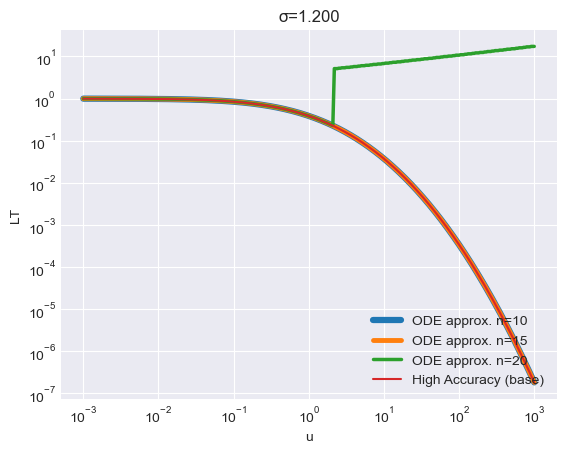

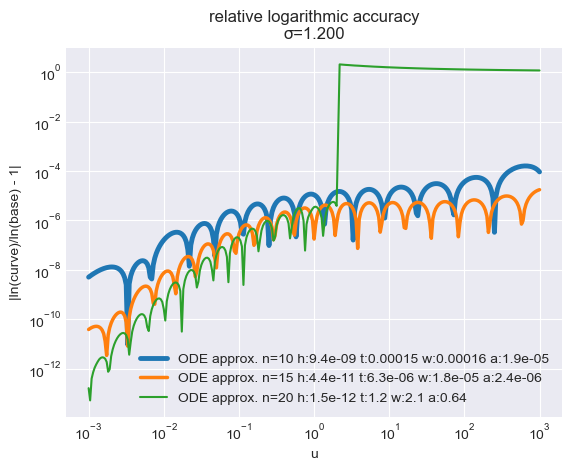

In [7]:
import sys
import mpmath as mp
import matplotlib.pyplot as plt
import scipy.integrate as scint
plt.style.use('seaborn-v0_8-darkgrid')
%run -i HA_integration.py
%run -i laplace_plots.py

v = 1.44
methods_list = (
        ('High Accuracy', LTLN_DI_HA_real_uvF(101)),
        ('ODE approx. n=10', LTLN_ODE_real_uvF(10)),
        ('ODE approx. n=15', LTLN_ODE_real_uvF(15)),
        ('ODE approx. n=20', LTLN_ODE_real_uvF(20)),
        )
LT_plot(v, methods_list, spread=3, accuracy_only=False, linear=False, npoints=301,print_more=True)

The last plot shows the deviation measures: $h$ — deviation at the beginning of the graph, $t$ — deviation at the end, $w$ — maximum deviation on the graph, $a$ — average. Deviation is understood as the relative deviation of the logarithm of the approximation $c$ from the reference value $b$:
$$D(c,b)=\left|\frac{\ln c}{\ln b}-1\right|.$$
In the present setting this is
$$\left|\frac{p_0(u)}{\ln\mathcal{L}(u)}-1\right|.$$
The relative error of $\mathcal{L}$ itself equals $|\ln c-\ln b|\approx|\ln\mathcal{L}(u)|\cdot D$; thus for large $u$ it is larger than $D$ by a factor $|\ln\mathcal{L}(u)|$ (approximately 16 at $u=10^3$, $v=1.44$).

As $n$ grows the error first decreases rapidly, but beyond a certain $n_{\max}$ it begins to increase, and for still larger $n$ the solution breaks down completely. For $v=1.44$ and $n=20$ system (1) becomes essentially non-integrable near $u\approx2.3$: `solve_ivp` almost stalls, while `odeint` issues a warning and thereafter returns garbage — exactly what is visible on the plot. Consequently the default solver in this cell is left as `odeint`, which at least fails quickly. The value of $n_{\max}$ depends strongly on $v$. The pattern of an initial decrease of the error followed by growth is typical of asymptotic series, so the family (1) behaves like an asymptotic expansion, even though it produces very accurate approximations, especially for small $v$.

Below, $n_{\max}$ is the order after which the maximum error on $u\in(0,50]$ first increases, together with the corresponding logarithmic accuracy.

In [6]:
u_max, u_len = 50., 10001
u = np.linspace(0, u_max, u_len)
ini_v = np.zeros(100)
v_set = np.arange(.5, 4.75, 0.25)
n_max = []
accuracy = []
for v in v_set:
    base = np.log(LTLN_DI_HA_real_uvF(101)(u[1:], v))
    ini_v[2] = 0.5 * v
    pd = 100.
    for n in range(4, 100):
        S = get_S(n)
        g_k = get_gF(n, S)
        r = ode_int(lambda p, t: g_k(p[1:]), ini_v[:n+1], u, solve_ivp=True)
        d = np.max(np.abs(r[1:] / base - 1))
        if d > pd:
            print(f'v={v:<4.2f}, n_max={n-1:<2d}, max|1-p0/ln L|={pd:>8.3e}')
            n_max.append(n-1)
            accuracy.append(pd)
            break
        pd = d

v=0.50, n_max=34, max|1-p0/ln L|=2.228e-11


v=0.75, n_max=28, max|1-p0/ln L|=7.727e-09


v=1.00, n_max=22, max|1-p0/ln L|=1.874e-07


v=1.25, n_max=19, max|1-p0/ln L|=1.451e-06


v=1.50, n_max=17, max|1-p0/ln L|=6.223e-06


...

v=3.50, n_max=10, max|1-p0/ln L|=7.564e-04


v=3.75, n_max=10, max|1-p0/ln L|=1.002e-03


v=4.00, n_max=10, max|1-p0/ln L|=1.296e-03


v=4.25, n_max=9 , max|1-p0/ln L|=1.635e-03


v=4.50, n_max=9 , max|1-p0/ln L|=1.986e-03


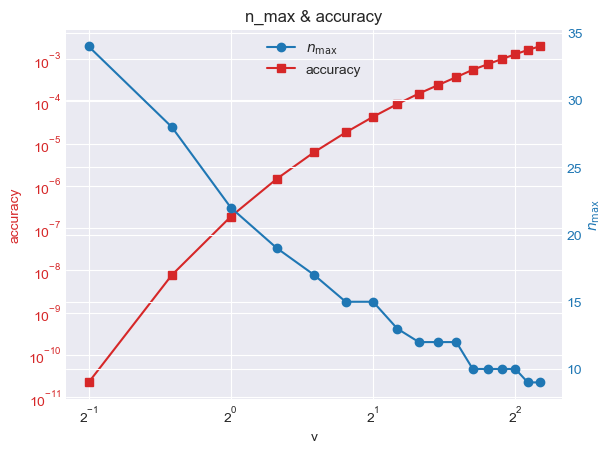

In [10]:
fig, ax2 = plt.subplots()
line2 = ax2.plot(v_set, accuracy, color='tab:red', label='accuracy', marker='s')
ax2.set_xlabel('v')
ax2.set_xscale('log', base=2)
ax2.set_ylabel('accuracy', color='tab:red')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1 = ax2.twinx()

line1 = ax1.plot(v_set, n_max, color='tab:blue', label=r'$n_\text{max}$', marker='o')
ax1.set_xscale('log', base=2)
ax1.set_ylabel(r'$n_\text{max}$', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center')

plt.title('n_max & accuracy')
plt.show()

## Improving the convergence of the ODE scheme

### Damping of the highest-order coefficients $p_k$

Analysis shows that, for a fixed $n$, the coefficients $p_k$ produced by the scheme deviate more and more strongly from the true values $\kappa_k/k!$ as $k$ approaches $n$. A simple remedy is to damp those $p_k$ that are close to $n$: inside $Q(z)$ one replaces $p_{k+1}$ by $w_k p_{k+1}$ with the weights
$$w_k=\exp\Bigl(-c\Bigl(\frac{k}{n-1}\Bigr)^q\Bigr),\qquad k=0,\dots,n-1,$$
so that $p_1$ enters unchanged while $p_n$ is reduced by the factor $e^c$.

In [11]:
def high_k_filter(n, c=5., q=7.0):
    return np.exp(-c * (np.arange(n) / (n-1)) ** q)

Redefine the matrix-construction routine so that the damping weights multiply the rows of $\mathbf{S}$:

In [12]:
def get_damping_S(n, c=5., q=7.0):
    S = np.zeros((n, n))
    for i in range(n):
        S[i, 0] = 1   # row that produces q_0
        for j in range(1, i+1):
            S[i, j] = j * scsp.comb(i+1, j, exact=True)  # row that produces j*q_j
    flt = high_k_filter(n, c, q)
    return np.diag(flt) @ S

def LTLN_ODE_damping_uvF(order, rtol=5e-13, atol=1e-18, c=5., q=7.0, solve_ivp=False):
    """Return laplace_fn(u, v) that approximates L_v(u) for the log-normal law (0, v)
    with damping of the higher-order p_k.

    order  -- number of equations
    c, q   -- parameters of the damping weights exp(-c (k/(n-1))^q)
    Example:
        f = LTLN_ODE_damping_uvF(15)
        u = np.linspace(0, 50, 10001)
        f(u, 1.44)
    """
    S = get_damping_S(order, c, q)
    g_k = get_gF(order, S)

    def laplace_fn(u, v):
        u = np.atleast_1d(np.asarray(u, dtype=float))
        grid = u if u[0] == 0 else np.r_[0.0, u]
        ini = np.zeros(order + 1)
        ini[2] = 0.5 * v
        p0 = ode_int(lambda p, t: g_k(p[1:]), ini, grid, rtol=rtol, atol=atol, solve_ivp=solve_ivp)
        return np.exp(p0) if u[0] == 0 else np.exp(p0[1:])

    laplace_fn.order = order
    return laplace_fn


Compare the damped and undamped schemes:

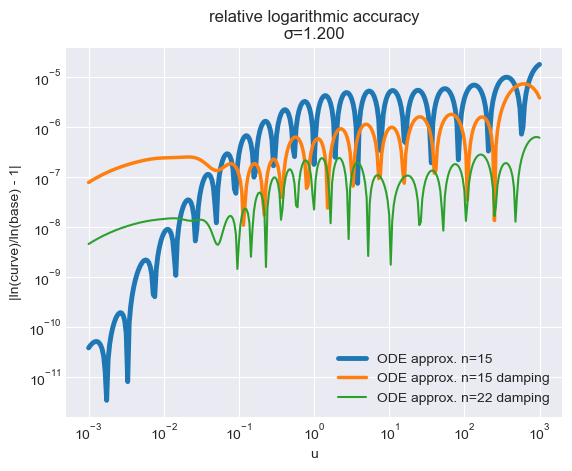

In [14]:
v = 1.44
methods_list = (
        ('High Accuracy', LTLN_DI_HA_real_uvF(101)),
        ('ODE approx. n=15', LTLN_ODE_real_uvF(15)),
        ('ODE approx. n=15 damping', LTLN_ODE_damping_uvF(15)),
        ('ODE approx. n=22 damping', LTLN_ODE_damping_uvF(22)),
        )
LT_plot(v, methods_list, spread=3, accuracy_only=True, linear=False, npoints=301)


For a fixed $n$, damping slightly degrades accuracy at very small $u$ (a few hundredths) and improves it elsewhere. The degradation at small $u$ is expected: there the higher-order $p_k$ are still tiny and are computed exactly ($\kappa_k=O(u)$ for $k\neq2$), so the artificial damping merely introduces a bias. On the other hand the device permits one to work at higher $n$ and thereby obtain a net gain in accuracy. The resulting $n_{\max}$ and accuracy figures are shown below.

In [15]:
u_max, u_len = 50., 10001
u = np.linspace(0, u_max, u_len)
ini_v = np.zeros(100)
v_set2 = np.arange(1., 4.75, 0.25)
n_max2 = []
accuracy2 = []
for v in v_set2:
    base = np.log(LTLN_DI_HA_real_uvF(101)(u[1:], v))
    ini_v[2] = 0.5 * v
    pd = 100.
    for n in range(4, 100):
        S = get_damping_S(n, c=5.)
        g_k = get_gF(n, S)
        r = ode_int(lambda p, t: g_k(p[1:]), ini_v[:n+1], u, solve_ivp=True)
        d = np.max(np.abs(r[1:] / base - 1))
        if d > pd:
            print(f'v={v:<4.2f}, n_max={n-1:<2d}, max|1-p0/ln L|={pd:>8.3e}')
            n_max2.append(n-1)
            accuracy2.append(pd)
            break
        pd = d

v=1.00, n_max=25, max|1-p0/ln L|=1.290e-08


v=1.25, n_max=23, max|1-p0/ln L|=7.143e-08


v=1.50, n_max=21, max|1-p0/ln L|=4.209e-07


v=1.75, n_max=19, max|1-p0/ln L|=2.244e-06


v=2.00, n_max=17, max|1-p0/ln L|=7.150e-06


...

v=3.50, n_max=13, max|1-p0/ln L|=2.189e-04


v=3.75, n_max=12, max|1-p0/ln L|=3.035e-04


v=4.00, n_max=12, max|1-p0/ln L|=3.986e-04


v=4.25, n_max=12, max|1-p0/ln L|=5.102e-04


v=4.50, n_max=12, max|1-p0/ln L|=6.415e-04


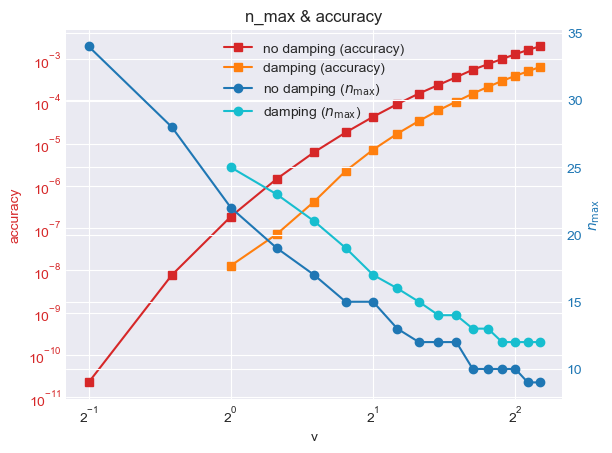

In [16]:
fig, ax2 = plt.subplots()
line1 = ax2.plot(v_set, accuracy, color='tab:red', label='no damping (accuracy)', marker='s')
line2 = ax2.plot(v_set2, accuracy2, color='tab:orange', label='damping (accuracy)', marker='s')
ax2.set_xlabel('v')
ax2.set_xscale('log', base=2)
ax2.set_ylabel('accuracy', color='tab:red')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1 = ax2.twinx()

line3 = ax1.plot(v_set, n_max, color='tab:blue', label=r'no damping ($n_\text{max}$)', marker='o')
line4 = ax1.plot(v_set2, n_max2, color='tab:cyan', label=r'damping ($n_\text{max}$)', marker='o')
ax1.set_xscale('log', base=2)
ax1.set_ylabel(r'$n_\text{max}$', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center')

plt.title('n_max & accuracy')
plt.show()

### Completing the series of coefficients $p_k$

Instead of truncating the true series
$$\mathcal{C}(z)=\sum_{k=0}^\infty p_k z^k$$
by setting $p_{n+1}=p_{n+2}=\dots=0$ and obtaining
$$\mathcal{C}_n(z)=p_0+p_1 z+p_2 z^2+\dots+p_n z^n,$$
one may append an explicit estimate of the tail $p'_{n+1},p'_{n+2},\dots$:
$$\Psi:(u,v)\mapsto(p'_{n+1},p'_{n+2},\dots),$$
thereby producing
$$\mathcal{C}_n(z)=p_0+p_1 z+p_2 z^2+\dots+p_n z^n+\sum_{k=n+1}^\infty p'_k z^k.$$
 Crucially, the tail coefficients $p'_k$ are explicit functions of $u$ and $v$ that do not depend on the current values of $p_0,\dots,p_n$, so the system (1) remains closed and of dimension $n+1$.

The completing map $\Psi$ is constructed as follows.

For fixed $u>0$ the function
$$\mathcal{M}(z)=\int_{\mathbb{R}}\exp\bigl(z\cdot x-u\cdot e^x\bigr)\phi(x)\,dx$$
is an entire function of order 2. Indeed, $|\mathcal{M}(z,u)|\le\mathcal{M}(\operatorname{Re}z,u)\le\mathcal{M}(\operatorname{Re}z,0)=e^{v(\operatorname{Re}z)^2/2}$, so the order is at most 2; along the negative real axis, where the factor $e^{-ue^x}$ is almost inactive, $\mathcal{M}$ grows exactly like $e^{vz^2/2}$. On the real line $\mathcal{M}>0$, hence there are no real zeros; complex zeros appear in conjugate pairs because $\mathcal{M}(\overline{z})=\overline{\mathcal{M}(z)}$. Hadamard’s factorization theorem therefore yields
$$\mathcal{M}(z)=e^{az^2+bz+c}\prod_{j=1}^\infty\Bigl(1-\frac{z}{z_j}\Bigr)\Bigl(1-\frac{z}{\overline{z}_j}\Bigr)\exp\Bigl(\frac{z}{z_j}+\frac{z^2}{2z_j^2}\Bigr)\exp\Bigl(\frac{z}{\overline{z}_j}+\frac{z^2}{2\overline{z}_j^2}\Bigr),$$
where $z_j$ are the zeros of $\mathcal{M}$ that lie in the upper half-plane (counted with multiplicity) and $\overline{z}_j$ are their conjugates. 

The cumulant-generating function $\mathcal{C}(z)$ is the logarithm of $\mathcal{M}(z)$. Setting $r_j=1/z_j$ one obtains
$$\mathcal{C}(z)=az^2+bz+c+\sum_{j=1}^\infty\Bigl[\ln(1-r_j z)+r_j z+\frac{r_j^2}{2}z^2+\ln(1-\overline{r}_j z)+\overline{r}_j z+\frac{\overline{r}_j^2}{2}z^2\Bigr].$$
In general one cannot split this sum into a quadratic polynomial plus a pure sum of logarithms: only $\sum_j|r_j|^{2+\varepsilon}<\infty$ is known, while the series $\sum_j r_j$ and $\sum_j r_j^2$ may diverge. For the coefficients of $z^k$ with $k\ge3$, however, the quadratic terms are irrelevant: $[z^k]\ln(1-r_j z)=-r_j^k/k$ and the series $\sum_j|r_j|^k$ converges absolutely for $k\ge3$. Consequently
$$p_k=[z^k]\mathcal{C}(z)=-\frac2k\sum_{j=1}^\infty\operatorname{Re}(r_j^k),\qquad k\ge3. \tag{2}$$
In other words, for $k\ge3$ the coefficients of $\mathcal{C}$ coincide with those of the function $2\sum_j\operatorname{Re}\ln(1-r_j z)$; here $z$ is a formal variable that may be treated as real, so that $\ln(1-\overline{r}_j z)=\overline{\ln(1-r_j z)}$.

To obtain the approximate tail coefficients $p'_{n+1},p'_{n+2},\dots$ (for $n\ge2$) one retains only the first $m$ (e.g. $m=2$) terms of (2):
$$p'_k=-\frac2k\sum_{j=1}^m\operatorname{Re}(r_j^k)=2[z^k]\sum_{j=1}^m\operatorname{Re}\ln(1-r_j z),\qquad k=n+1,n+2,\dots.$$
Which zeros are regarded as “first” is discussed below. Define $p'_k=0$ for $k=0,\dots,n$ and set
$$T_m(z)=\sum_{j=1}^m\operatorname{Re}\Bigl(\ln(1-r_j z)+\sum_{k=1}^n\frac{r_j^k}{k}z^k\Bigr).$$
The added finite sum precisely cancels the first $n$ Taylor coefficients of $T_m$, while for $k>n$ one has $[z^k]2T_m(z)=p'_k$. The completed generating function therefore reads
$$\mathcal{C}_{n,m}(z)=\sum_{k=0}^n p_k z^k+2T_m(z)=p_0+\sum_{k=1}^n\Bigl(p_k+\frac2k\sum_{j=1}^m\operatorname{Re}(r_j^k)\Bigr)z^k+2\sum_{j=1}^m\operatorname{Re}\ln(1-r_j z). \tag{3}$$
The logarithmic terms supply the tail $p'_{n+1},p'_{n+2},\dots$, while the corrections added to the $p_k$ compensate for the influence of those terms on the first $n$ coefficients. 

#### Evaluation of $[z^k]\Delta_z\mathcal{C}_{n,m}(z,u)$

Recall that the quantities $g_k=[z^k]e^{\Delta_z\mathcal{C}_{n,m}(z,u)}$ are computed by the recurrence
$$g_k=\frac1k\sum_{j=1}^{\min(k,n-1)}j q_j g_{k-j},\qquad g_0=e^{q_0},$$
where the $q_j$ are the coefficients of the series $Q(z):=\Delta_z\mathcal{C}_{n,m}(z,u)$ and only $q_0,\dots,q_n$ are needed. Previously $\Delta_z\mathcal{C}_n$ was a polynomial of degree $n-1$ and $q_n=0$; now the logarithmic terms of $\mathcal{C}_{n,m}$ (together with the compensating corrections to $p_1,\dots,p_n$) make $Q(z)$ an infinite series. Although only its first $n+1$ coefficients are required, those coefficients feel the influence of the whole infinite tail $p'_{n+1},p'_{n+2},\dots$ introduced by the logarithms, because the binomial expansion of $\Delta_z z^k=(1+z)^k-z^k$ contains every lower power of $z$.

Consider the series for $\Delta_z\ln(1-rz)$ for a fixed $r$:
$$\Delta_z\ln(1-rz)=\ln\bigl(1-r(z+1)\bigr)-\ln(1-rz)=\ln(1-r)+\ln\Bigl(1-\frac{rz}{1-r}\Bigr)-\ln(1-rz).$$
Using the ordinary expansion
$$\ln(1-az)=-\sum_{k=1}^\infty\frac{a^k z^k}{k},\qquad|az|<1,$$
one obtains
$$\Delta_z\ln(1-rz)=\ln(1-r)-\sum_{k=1}^\infty\frac1k\Bigl(\frac{r}{1-r}\Bigr)^k z^k+\sum_{k=1}^\infty\frac{r^k z^k}{k}.$$
Hence, writing $t=r/(1-r)$,
$$\Delta_z\ln(1-rz)=\ln(1-r)+\sum_{k=1}^\infty\frac{r^k}{k}\Bigl(1-\frac1{(1-r)^k}\Bigr)z^k=\ln(1-r)+\sum_{k=1}^\infty\frac{r^k-t^k}{k}z^k.$$
This is the Taylor series at the origin of the function $\ln(1-r(1+z))-\ln(1-rz)$; it exists for every $r\neq1$, which is guaranteed because the zeros are non-real. For the real part of the constant term the choice of branch is immaterial: $\operatorname{Re}\ln(1-r)=\ln|1-r|$.

Consequently the scaled coefficients $(q_0,q_1,2q_2,\dots,n q_n)$ that appear in the code become
$$
q_0=\bigl[\mathbf{p}'_1{}^T\mathbf{S}\bigr]_0+2\sum_{j=1}^m\ln|1-r_j|,\qquad
k q_k=\bigl[\mathbf{p}'_1{}^T\mathbf{S}\bigr]_k+2\sum_{j=1}^m\operatorname{Re}(r_j^k-t_j^k),\quad k=1,\dots,n,
$$
where $t_j=r_j/(1-r_j)$, $\mathbf{S}$ is the scaled matrix produced by `get_S` (it has $n$ columns, so $\bigl[\mathbf{p}'_1{}^T\mathbf{S}\bigr]_n=0$), and $\mathbf{p}'_1$ is the column vector
$$\Bigl(p_1+2\sum_{j=1}^m\frac{\operatorname{Re}(r_j)}{1},\;p_2+2\sum_{j=1}^m\frac{\operatorname{Re}(r_j^2)}{2},\;\dots,\;p_n+2\sum_{j=1}^m\frac{\operatorname{Re}(r_j^n)}{n}\Bigr).$$

#### Relation between the zeros of $\mathcal{M}(z,1)$ and those of $\mathcal{M}(z,u)$

Make the change of variable $x=y-\ln u$ in the integral that defines $\mathcal{M}(z,u)$. Since $u e^x=e^y$ and
$$\phi(y-\ln u)=\phi(y)\exp\Bigl(\frac{y\ln u}{v}-\frac{(\ln u)^2}{2v}\Bigr),$$
one obtains, for every complex $z$,
$$\mathcal{M}(z,u)=\exp\Bigl(-z\ln u-\frac{(\ln u)^2}{2v}\Bigr)\int_{\mathbb{R}}\exp\Bigl(\bigl(z+\tfrac{\ln u}{v}\bigr)y-e^y\Bigr)\phi(y)\,dy=\exp\Bigl(-z\ln u-\frac{(\ln u)^2}{2v}\Bigr)\mathcal{M}\Bigl(z+\tfrac{\ln u}{v},1\Bigr). \tag{4}$$
The prefactor never vanishes. Therefore $z^*$ is a zero of $\mathcal{M}(z,1)$ if and only if
$$z=z^*-\frac{\ln u}{v}$$
is a zero of $\mathcal{M}(z,u)$ of the same multiplicity. The horizontal shift $z^*_j\mapsto z_j=z^*_j-\ln u/v$ establishes a one-to-one correspondence between the zeros of the two functions and preserves the upper half-plane. Consequently it is enough to compute the zeros once, for $u=1$, and then express the $r_j$ appearing in (3) by
$$r_j(u)=\frac{v}{v z^*_j-\ln u}.$$
As $u\to+0$ every $r_j\to0$ and the completion disappears, which is consistent with the initial condition $\mathcal{C}(z,0)=vz^2/2$.

**Choice of zeros.** When $u$ varies all zeros are translated by the same real amount $-\ln u/v$, so their ordering by modulus depends on $u$. For the ODE the set of zeros must be fixed; otherwise the right-hand side would jump whenever the ordering changes. A natural choice is the $m$ zeros of $\mathcal{M}(z,1)$ that possess the smallest imaginary parts: since $\min_u|z_j(u)|=\operatorname{Im}z^*_j$, one has $\max_u|r_j(u)|=1/\operatorname{Im}z^*_j$, and these zeros come closest to the origin for some value of $u$.



#### Computation of the zeros of $\mathcal{M}(z,1)$

For complex $z$ the integrand of $\mathcal{M}(z,1)$ oscillates, so a direct quadrature is inconvenient. Reading (4) from right to left with $u=e^c$ ($c$ real) yields
$$\mathcal{M}(z,1)=\exp\Bigl(zc-\frac{c^2}{2v}\Bigr)\int_{\mathbb{R}}\exp\Bigl(\bigl(z-\tfrac{c}{v}\bigr)y-e^c e^y\Bigr)\phi(y)\,dy.$$
Choose $c$ so that the real part of the exponent (together with $\ln\phi$) attains its maximum at $y=0$: $\operatorname{Re}z-c/v=e^c$, i.e.
$$c=v\operatorname{Re}z-W(v e^{v\operatorname{Re}z}),$$
where $W$ is the principal branch of the Lambert function. The integrand then becomes a smooth “hump” of width of order $\sqrt{v}$, multiplied by the oscillatory factor $e^{i\operatorname{Im}z\cdot y}$. For entire functions of rapid decay the trapezoidal rule converges exponentially fast; 400 nodes on the interval $[-9\sqrt{v},\,4.5-c+1]$ already give near-machine accuracy. The derivative needed by Newton’s method is obtained simply by multiplying the integrand by $y+c$.

An initial guess is taken from the empirically observed near-linear dependence of the products $v z^*_j$ on $\sqrt{v}$: a quadratic fit on the interval $v\in[0.8,9]$ errs by at most $0.08$, which is more than sufficient.  After Newton iteration, we verify that the result is a new zero: $|\mathcal{M}|$ there must be many orders of magnitude smaller than at nearby points (the “|M| drop”), and the zero must differ from those already found.

For $v\gtrsim0.7$ the first two zeros are found reliably. For smaller $v$ the zeros recede high into the complex plane ($\operatorname{Im}z^*_1\approx7.0$ already at $v=0.6$). In double-precision arithmetic the zeros cease to be recoverable near $v=0.5$. At such low values of $v$, however, series completion is unnecessary: $|r_j|\le1/\operatorname{Im}z^*_j<0.2$, the contribution of the tail $p'_k$ is of order $|r_j|^{n+1}$ and is negligible, while the original undamped scheme already attains an accuracy of about $10^{-11}$.

In [17]:
import warnings

_trap_t = np.linspace(0.0, 1.0, 401)   # nodes of the trapezoidal rule on [0,1]

def M1(z, v, deriv=False):
    """M(z,1) and (when deriv=True) M'(z,1) for a complex scalar or array z.

    After the shift y = x - c with c = v Re z - W(v exp(v Re z)),
    the integral is evaluated by the trapezoidal rule.
    """
    c = v * z.real - np.real(scsp.lambertw(v * np.exp(v * z.real)))
    lo, hi = -9.0 * np.sqrt(v), 4.5 - c + 1.0
    h = (hi - lo) * _trap_t[1]
    y = lo + (hi - lo) * _trap_t
    f = np.exp((z - c / v) * y - np.exp(y + c) - y * y / (2 * v))
    pref = np.exp(z * c - 0.5 * c * c / v) / np.sqrt(2 * np.pi * v)
    M = pref * scint.trapezoid(f, dx=h)
    if deriv:
        return M, pref * scint.trapezoid((y + c) * f, dx=h)
    return M

# seeds: v*z_j^* ~ a*v + b*sqrt(v) + c, fitted on v in [0.8,9]
_SEED = ((0.2061 + 0.1251j, -3.0946 + 1.8530j, 1.0520 + 2.7096j),
         (0.1555 + 0.0369j, -4.1893 + 3.3432j, 1.4557 + 2.3842j))

def M1_roots(v, m=2, tol=1e-10, maxit=50):
    """First m (at most 2) zeros of M(z,1) in the upper half-plane,
    ordered by imaginary part.
    """
    roots = []
    best_z, best_st, stall, stall_max = None, np.inf, 0, 4

    for a, b, c in _SEED[:m]:
        z = (a * v + b * np.sqrt(v) + c) / v
        step = 1.0
        for it in range(maxit):
            M, dM = M1(z, v, deriv=True)
            step = M / dM
            if abs(step) > 0.25:            # step-size restriction to stay inside the correct basin
                step *= 0.25 / abs(step)
            z -= step
            if abs(step) < tol * abs(z):
                break

        drop = abs(M1(z, v)) / min(abs(M1(z + d, v)) for d in (0.1, -0.1, 0.1j, -0.1j))
        if drop < 1e-5 and all(abs(z - w) > 1e-3 for w in roots):
            roots.append(complex(z))
        else:
            warnings.warn(f'M1_roots: zero {len(roots)+1} at v={v} not found; continuing with fewer zeros')
            break
    return np.array(roots)

Verification of the zeros: magnitude of $|\mathcal{M}|$ at a zero relative to neighbouring points, and $\max_u|r_j(u)|=1/\operatorname{Im}z^*_j$.

In [18]:
for v in (0.8, 1.2, 2.0, 3.0, 4.5):
    zs = M1_roots(v)
    for j, z in enumerate(zs, 1):
        drop = abs(M1(z, v)) / min(abs(M1(z + d, v)) for d in (0.1, -0.1, 0.1j, -0.1j))
        print(f'v={v:4}  z{j}* = {z.real:+.6f}{z.imag:+.6f}j   |M| drop {drop:.1e}   max|r| = {1/z.imag:.3f}')

v= 0.8  z1* = -1.842844+5.609982j   |M| drop 5.3e-10   max|r| = 0.178
v= 0.8  z2* = -2.651672+6.788976j   |M| drop 6.2e-08   max|r| = 0.147
v= 1.2  z1* = -1.736107+4.077158j   |M| drop 7.4e-12   max|r| = 0.245
v= 1.2  z2* = -2.454019+5.077211j   |M| drop 4.0e-09   max|r| = 0.197
v= 2.0  z1* = -1.468263+2.786650j   |M| drop 6.5e-13   max|r| = 0.359
v= 2.0  z2* = -2.085614+3.588576j   |M| drop 8.8e-11   max|r| = 0.279
v= 3.0  z1* = -1.234614+2.096500j   |M| drop 4.0e-13   max|r| = 0.477
v= 3.0  z2* = -1.779999+2.760460j   |M| drop 2.3e-11   max|r| = 0.362
v= 4.5  z1* = -1.017000+1.601279j   |M| drop 6.1e-14   max|r| = 0.625
v= 4.5  z2* = -1.494764+2.143467j   |M| drop 4.5e-12   max|r| = 0.467


It remains only to write the right-hand side of system (1) with the completed series. Relative to `get_gF` the only changes are the addition of the compensating terms to $\mathbf{p}_1$ and of the logarithmic contributions to $(q_0,\dots,n q_n)$; when $u=0$ all $r_j$ vanish and the completion is absent.

In [19]:
def get_tail_gF(n, S, zs, v):
    """Like get_gF, but with the series tail completed by means of the zeros zs of M(z,1).
    Returns g_k(p1, u).
    """
    k = np.arange(1, n + 1)
    zs = np.asarray(zs, dtype=complex)
    def g_k(p1, u):
        if u > 0 and zs.size:
            r = v / (v * zs - np.log(u))                  # r_j(u)
            t = r / (1.0 - r)
            rk = r[:, None] ** k
            tk = t[:, None] ** k
            p1 = p1 + 2.0 * rk.real.sum(0) / k       # compensating terms
            q = np.append(p1 @ S, 0.0)               # (q_0, q_1, 2q_2, ..., n q_n), q_n = 0
            q[0] += 2.0 * np.log(np.abs(1.0 - r)).sum()
            q[1:] += 2.0 * (rk - tk).real.sum(0)     # k q_k += 2 sum Re(r_j^k - t_j^k)
        else:
            q = np.append(p1 @ S, 0.0)               # (q_0, q_1, 2q_2, ..., n q_n), q_n = 0
        q = q.tolist()
        g = [np.exp(q[0])]
        for kk in range(1, n + 1):
            s = 0.0
            for j in range(kk):
                s += q[kk - j] * g[j]
            g.append(s / kk)
        return [-e for e in g]
    return g_k


def LTLN_ODE_tail_uF(v, order, m=2, rtol=5e-13, atol=1e-18, solve_ivp=True):
    """Return laplace_fn(u) that approximates L_v(u) for the log-normal law (0, v)
    with the series tail of C completed by m zeros of M(z,1).

    order  -- number of cumulant equations
    m      -- number of zeros (1 or 2)
    Example:
        f = LTLN_ODE_tail_uF(v, 20)
        u = np.linspace(0, 50, 10001)
        f(u)
    """
    S = get_S(order)
    zs = M1_roots(v, m)
    g_k = get_tail_gF(order, S, zs, v)

    def laplace_fn(u, v):
        u = np.atleast_1d(np.asarray(u, dtype=float))
        grid = u if u[0] == 0 else np.r_[0.0, u]
        ini = np.zeros(order + 1)
        ini[2] = 0.5 * v
        p0 = ode_int(lambda p, t: g_k(p[1:], t), ini, grid, rtol=rtol, atol=atol, solve_ivp=solve_ivp)
        return np.exp(p0) if u[0] == 0 else np.exp(p0[1:])

    laplace_fn.order = order
    laplace_fn.zeros = zs
    return laplace_fn

#### Numerical results for the completed-series scheme

By default `solve_ivp` is used here: on the completed scheme `odeint` produced spurious jumps on coarse grids and near $u=0$.

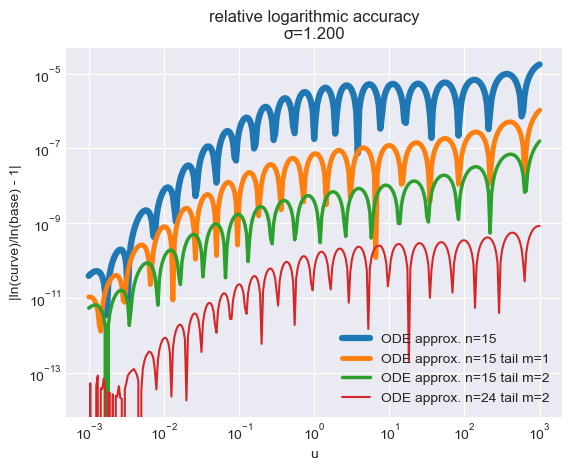

In [20]:
v = 1.44
methods_list = (
        ('High Accuracy', LTLN_DI_HA_real_uvF(101)),
        ('ODE approx. n=15', LTLN_ODE_real_uvF(15)),
        ('ODE approx. n=15 tail m=1', LTLN_ODE_tail_uF(v, 15, m=1)),
        ('ODE approx. n=15 tail m=2', LTLN_ODE_tail_uF(v, 15)),
        ('ODE approx. n=24 tail m=2', LTLN_ODE_tail_uF(v, 24)),
        )
LT_plot(v, methods_list, spread=3, accuracy_only=True, linear=False, npoints=301)


The completed scheme likewise breaks down for sufficiently large $n$; in that regime `solve_ivp` does not raise an exception but virtually stalls. Therefore the right-hand side in the loop below is wrapped by a call counter: if the number of evaluations exceeds `max_calls` the integration is regarded as having failed.

In [21]:
class Stalled(Exception):
    pass

def guarded(f, max_calls=100000):
    calls = [0]
    def h(p, t):
        calls[0] += 1
        if calls[0] > max_calls:
            raise Stalled
        return f(p, t)
    return h

u_max, u_len = 50., 10001
u = np.linspace(0, u_max, u_len)
ini_v = np.zeros(100)
v_set3 = np.arange(1., 4.75, 0.25)
n_max3 = []
accuracy3 = []
for v in v_set3:
    base = np.log(LTLN_DI_HA_real_uvF(101)(u[1:], v))
    ini_v[2] = 0.5 * v
    zs = M1_roots(v, 2)
    pd = 100.
    for n in range(4, 100):
        S = get_S(n)
        g_k = get_tail_gF(n, S, zs, v)
        try:
            r = ode_int(guarded(lambda p, t: g_k(p[1:], t)), ini_v[:n+1], u, solve_ivp=True)
            d = np.max(np.abs(r[1:] / base - 1))
        except Stalled:
            d = np.inf
        if d > pd:
            print(f'v={v:<4.2f}, n_max={n-1:<2d}, max|1-p0/ln L|={pd:>8.3e}')
            n_max3.append(n-1)
            accuracy3.append(pd)
            break
        pd = d

v=1.00, n_max=31, max|1-p0/ln L|=5.136e-12


v=1.25, n_max=27, max|1-p0/ln L|=5.833e-11


v=1.50, n_max=24, max|1-p0/ln L|=3.851e-10


v=1.75, n_max=22, max|1-p0/ln L|=1.497e-09


v=2.00, n_max=20, max|1-p0/ln L|=5.307e-09


...

v=3.50, n_max=15, max|1-p0/ln L|=3.693e-07


v=3.75, n_max=15, max|1-p0/ln L|=5.567e-07


v=4.00, n_max=14, max|1-p0/ln L|=9.885e-07


v=4.25, n_max=14, max|1-p0/ln L|=1.267e-06


v=4.50, n_max=13, max|1-p0/ln L|=2.378e-06


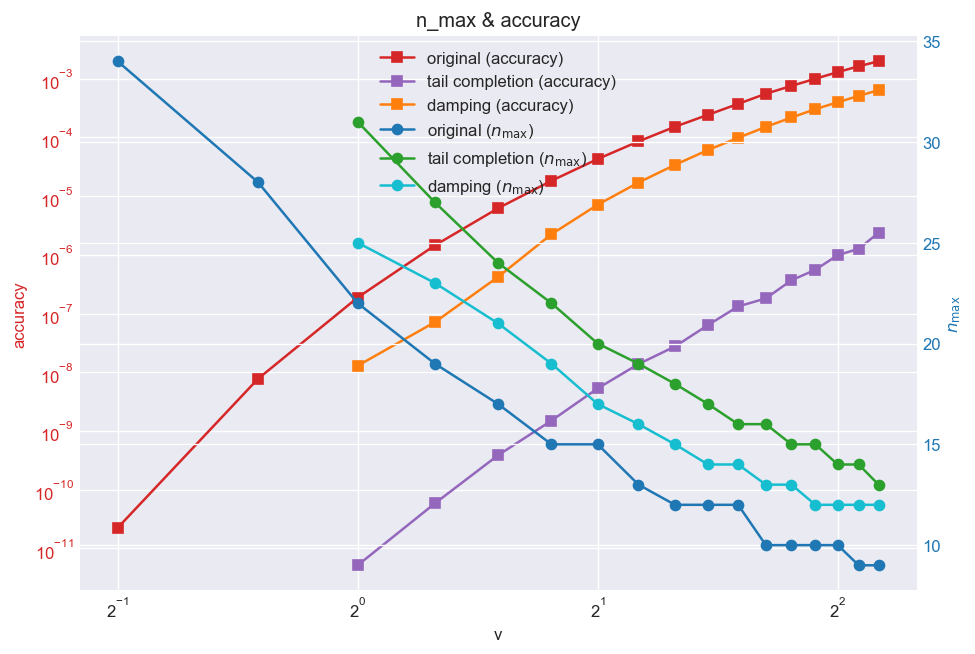

In [22]:
fig, ax2 = plt.subplots(figsize=(9, 6), dpi=120)
line1 = ax2.plot(v_set, accuracy, color='tab:red', label='original (accuracy)', marker='s')
line3 = ax2.plot(v_set3, accuracy3, color='tab:purple', label='tail completion (accuracy)', marker='s')
line2 = ax2.plot(v_set2, accuracy2, color='tab:orange', label='damping (accuracy)', marker='s')
ax2.set_xlabel('v')
ax2.set_xscale('log', base=2)
ax2.set_ylabel('accuracy', color='tab:red')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1 = ax2.twinx()

line4 = ax1.plot(v_set, n_max, color='tab:blue', label=r'original ($n_\text{max}$)', marker='o')
line6 = ax1.plot(v_set3, n_max3, color='tab:green', label=r'tail completion ($n_\text{max}$)', marker='o')
line5 = ax1.plot(v_set2, n_max2, color='tab:cyan', label=r'damping ($n_\text{max}$)', marker='o')
ax1.set_xscale('log', base=2)
ax1.set_ylabel(r'$n_\text{max}$', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

lines = line1 + line3 + line2 + line4 + line6 + line5
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center')

plt.title('n_max & accuracy')
plt.show()

## Conclusion

A new asymptotic scheme for evaluating the Laplace transform of a log-normally distributed random variable has been presented. The computation is reduced to the integration of an ordinary differential system of chosen dimension $n$. The scheme performs well for moderately small values of the logarithmic variance $v$ and yields high accuracy at small $u$, although the solution diverges once $n$ exceeds a certain threshold. Two devices that improve accuracy for larger $v$ have been described: a damping modification and a series-completion procedure that employs the zeros of $\mathcal{M}(z,1)$. The latter yields a substantial gain in accuracy. The method may find practical use in problems where one-dimensional Laplace transforms of log-normal random variables appear on the right-hand side of systems of ODEs — for example in population dynamics or SIR-type epidemic models. In such settings it is natural to augment the original ODE system by the additional equations derived here, thereby evaluating the required transforms “on the fly” at a modest extra cost.

